# Input Pipeline Visualization

End-to-end visualization from raw TFRecord parsing to fused multicrop tensors used for training.

This notebook reflects the new multicrop mode:
1. Raw parsed data (`peak_mz`, `peak_intensity`, `peak_valid_mask`)
2. Fixed valid/padding layout across all views (`fused_valid_mask`, `fused_padding_mask`)
3. View-specific masking metadata (`fused_masked_positions`)
4. Fused tensors consumed by the encoder (`fused_mz`, `fused_intensity`, `fused_precursor_mz`)
5. Summary diagnostics for global/local masking rates


In [1]:
import os
import sys
from pathlib import Path

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

project_root = Path('/home/wuhao/spectra-learning')
os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import torch

# Project imports
from input_pipeline import TfLightningDataModule, _build_dataset, _NUM_PEAKS_OUTPUT
from configs.gems_a_50_mask import get_config

plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})

cfg = get_config()
cfg.tfrecord_dir = '/home/wuhao/spectra-learning/data/gems_peaklist_tfrecord'
dm = TfLightningDataModule(cfg, seed=42)

print(f"Project root: {project_root}")
print(f"Train size: {dm.info['train_size']:,}")
print(f"Val size: {dm.info['validation_size']:,}")
print(f"Num peaks (output): {dm.info['num_peaks']}")
print(f"Peak ordering: {cfg.peak_ordering}")
print(f"Views: global={1}, local={cfg.multicrop_num_local_views}")
print('Masking policy: global view(s)=full spectra, local view(s)=local keep fraction')
print(f"Local keep fraction: {cfg.multicrop_local_keep_fraction:.2f}")


Project root: /home/wuhao/spectra-learning
Train size: 39,854,312
Val size: 2,097,596
Num peaks (output): 60
Peak ordering: mz
Views: global=1, local=5
Masking policy: global view(s)=full spectra, local view(s)=local keep fraction
Local keep fraction: 0.25


## 1. Raw Batch (Pre-Augmentation)

After TFRecord parsing, filtering, top-k selection, neutral-loss conversion, sorting, and normalization — but **before** two-view augmentation. This is what `_batched_parse_and_transform` produces.

In [2]:
# Build a dataset WITHOUT augmentation to see the raw parsed output
raw_ds = _build_dataset(
    dm.gems_train_files,
    batch_size=16,
    shuffle_buffer=1000,
    seed=42,
    drop_remainder=True,
    tfrecord_buffer_size=dm.tfrecord_buffer_size,
    max_precursor_mz=dm.max_precursor_mz,
    include_fingerprint=False,
    min_peak_intensity=dm.min_peak_intensity,
    augmentation_type='none',
    peak_ordering=cfg.peak_ordering,
)

raw_batch = next(raw_ds.as_numpy_iterator())
print('Raw batch keys:', list(raw_batch.keys()))
for k, v in raw_batch.items():
    print(f"  {k}: shape={v.shape}, dtype={v.dtype}, range=[{v.min():.4f}, {v.max():.4f}]")


Raw batch keys: ['peak_mz', 'peak_intensity', 'peak_valid_mask', 'precursor_mz', 'rt', 'mz', 'intensity']
  peak_mz: shape=(16, 60), dtype=float32, range=[0.0000, 0.5956]
  peak_intensity: shape=(16, 60), dtype=float32, range=[0.0000, 1.0000]
  peak_valid_mask: shape=(16, 60), dtype=bool, range=[0.0000, 1.0000]
  precursor_mz: shape=(16,), dtype=float32, range=[0.1140, 0.7986]
  rt: shape=(16,), dtype=float32, range=[14.6945, 717.8347]
  mz: shape=(16, 60), dtype=float32, range=[0.0000, 595.5851]
  intensity: shape=(16, 60), dtype=float32, range=[0.0000, 1.0000]


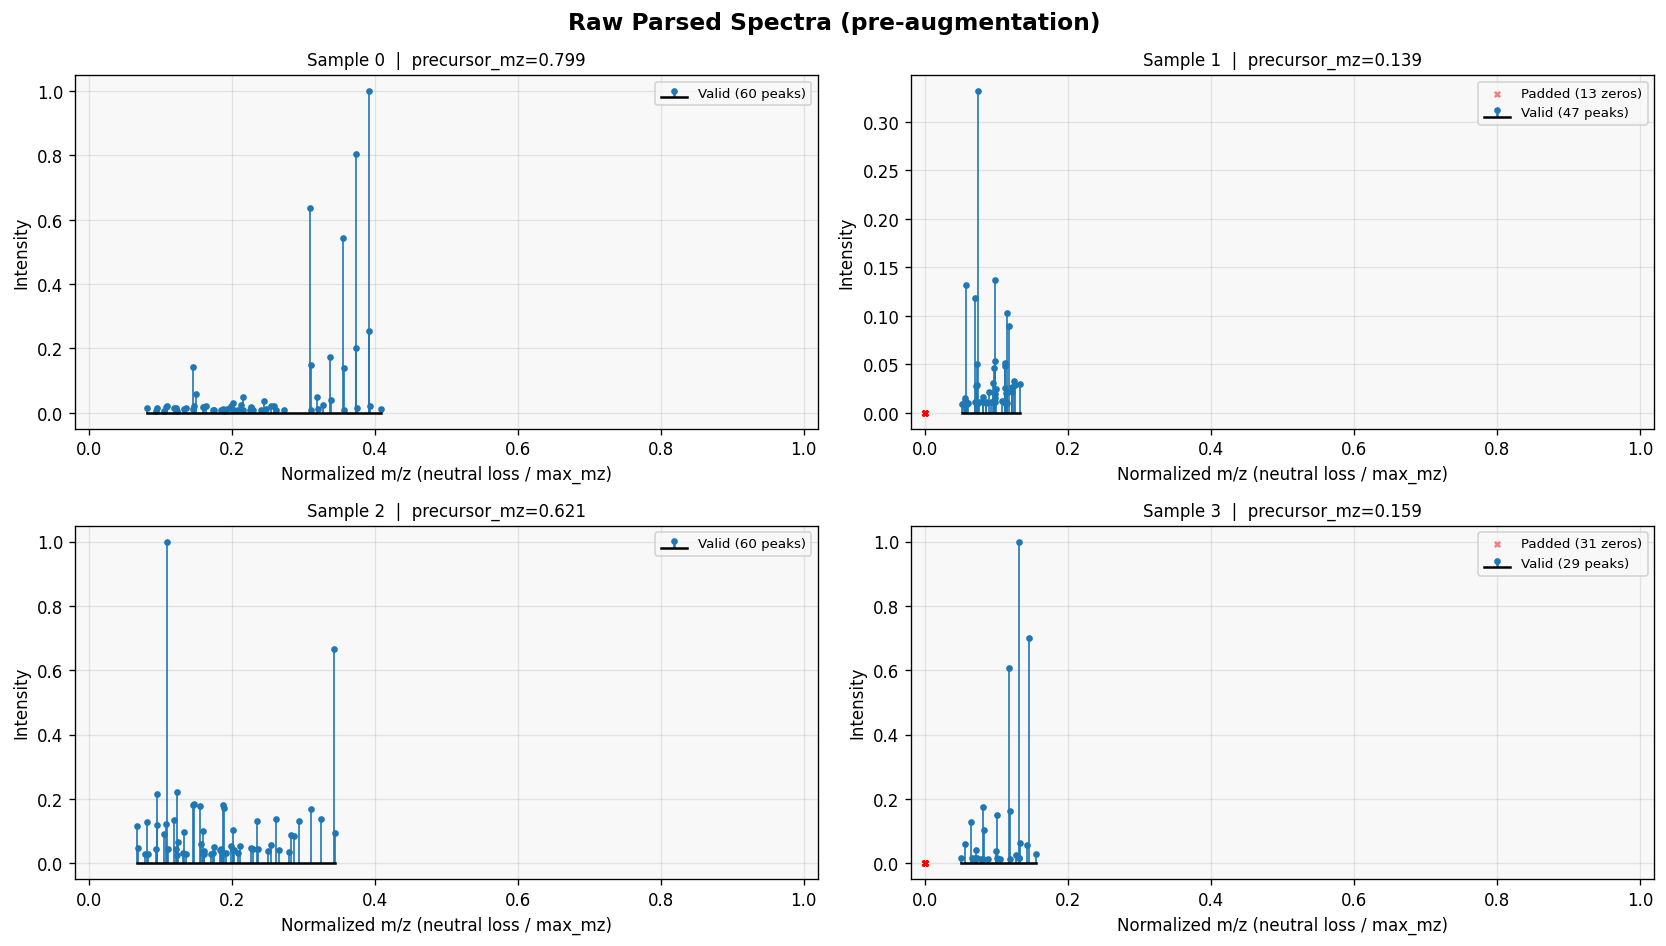

In [3]:
# Visualize 4 raw spectra: stem plots of mz vs intensity with valid mask overlay
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Raw Parsed Spectra (pre-augmentation)', fontsize=14, fontweight='bold')

for idx, ax in enumerate(axes.flat):
    mz = raw_batch['peak_mz'][idx]       # normalized [0,1]
    intensity = raw_batch['peak_intensity'][idx]
    valid = raw_batch['peak_valid_mask'][idx]
    prec = raw_batch['precursor_mz'][idx]
    
    # Valid peaks
    v_idx = np.where(valid)[0]
    p_idx = np.where(~valid)[0]
    
    markerline, stemlines, baseline = ax.stem(
        mz[v_idx], intensity[v_idx],
        linefmt='C0-', markerfmt='C0o', basefmt='k-',
        label=f'Valid ({len(v_idx)} peaks)',
    )
    stemlines.set_linewidth(1.0)
    markerline.set_markersize(3)
    
    if len(p_idx) > 0:
        ax.scatter(mz[p_idx], intensity[p_idx], c='red', s=10, marker='x',
                   alpha=0.5, label=f'Padded ({len(p_idx)} zeros)', zorder=5)
    
    ax.set_title(f'Sample {idx}  |  precursor_mz={prec:.3f}', fontsize=10)
    ax.set_xlabel('Normalized m/z (neutral loss / max_mz)')
    ax.set_ylabel('Intensity')
    ax.legend(fontsize=8)
    ax.set_xlim(-0.02, 1.02)

plt.tight_layout()
plt.savefig('notebooks/fig_raw_spectra.png', bbox_inches='tight')
plt.show()

## 2. Valid Mask & Padding Distribution

How many of the 60 peak slots are actually filled vs zero-padded across the batch?

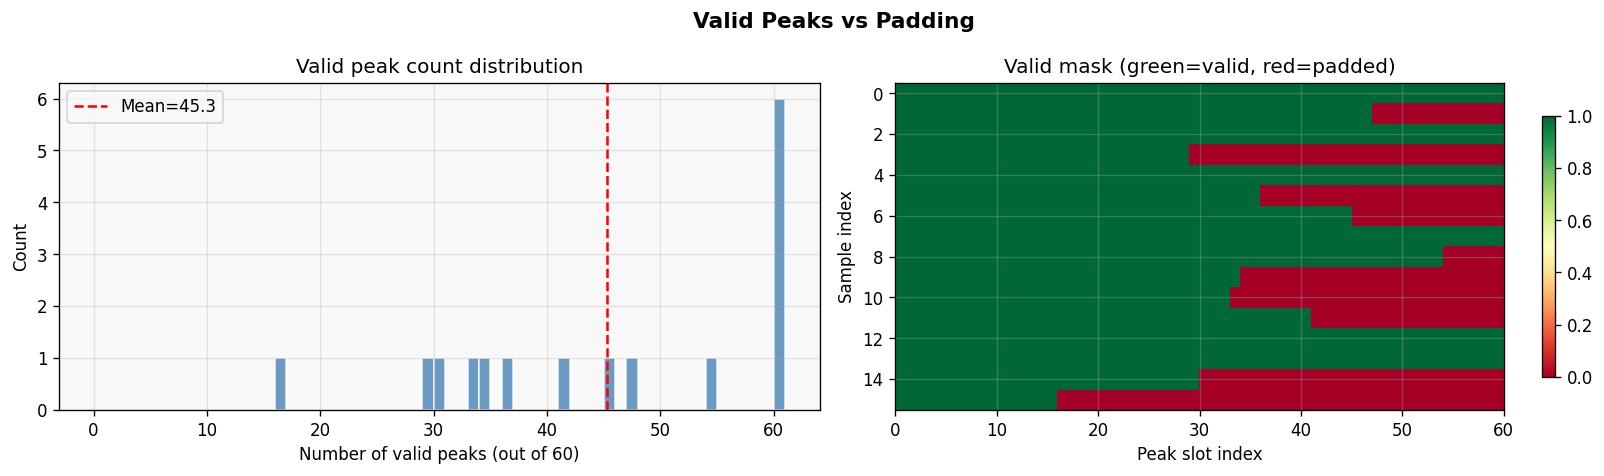

In [4]:
valid_counts = raw_batch['peak_valid_mask'].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Valid Peaks vs Padding', fontsize=13, fontweight='bold')

# Histogram of valid peak counts
ax = axes[0]
ax.hist(valid_counts, bins=range(0, _NUM_PEAKS_OUTPUT + 2), color='steelblue',
        edgecolor='white', alpha=0.8)
ax.axvline(valid_counts.mean(), color='red', ls='--', label=f'Mean={valid_counts.mean():.1f}')
ax.set_xlabel('Number of valid peaks (out of 60)')
ax.set_ylabel('Count')
ax.set_title('Valid peak count distribution')
ax.legend()

# Heatmap: each row is a sample, columns are peak slots, color = valid/padded
ax = axes[1]
im = ax.imshow(raw_batch['peak_valid_mask'][:16].astype(float),
               aspect='auto', cmap='RdYlGn', interpolation='nearest',
               extent=[0, _NUM_PEAKS_OUTPUT, 15.5, -0.5])
ax.set_xlabel('Peak slot index')
ax.set_ylabel('Sample index')
ax.set_title('Valid mask (green=valid, red=padded)')
plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig('notebooks/fig_valid_mask.png', bbox_inches='tight')
plt.show()

## 3. Multi-Crop Augmentation (Global Full + Local Masked)

Multi-crop uses one simple masking policy:
- Global view(s): full spectra (no masked positions).
- Local view(s): local masking percentage via `multicrop_local_keep_fraction`.
- `fused_valid_mask` preserves the same valid/padding layout for every view.
- `fused_masked_positions` carries the objective masking map.
- `fused_padding_mask`/`peak_padding_mask` explicitly mark padded slots.


In [5]:
# Build dataset WITH multicrop augmentation
aug_ds = _build_dataset(
    dm.gems_train_files,
    batch_size=16,
    shuffle_buffer=1000,
    seed=42,
    drop_remainder=True,
    tfrecord_buffer_size=dm.tfrecord_buffer_size,
    max_precursor_mz=dm.max_precursor_mz,
    include_fingerprint=False,
    min_peak_intensity=dm.min_peak_intensity,
    augmentation_type='multicrop',
    multicrop_num_local_views=cfg.multicrop_num_local_views,
    multicrop_local_keep_fraction=cfg.multicrop_local_keep_fraction,
    mz_jitter_std=cfg.sigreg_mz_jitter_std,
    intensity_jitter_std=cfg.sigreg_intensity_jitter_std,
    peak_ordering=cfg.peak_ordering,
)

aug_batch = next(aug_ds.as_numpy_iterator())
print('Augmented batch keys:', list(aug_batch.keys()))

B = raw_batch['peak_mz'].shape[0]
V = 1 + cfg.multicrop_num_local_views
print(f"\nV={V} views (global={1}, local={cfg.multicrop_num_local_views}), B={B}")
print(f"Fused tensors are [V*B, N] = [{aug_batch['fused_mz'].shape[0]}, {aug_batch['fused_mz'].shape[1]}]")
for k in [
    'fused_mz',
    'fused_intensity',
    'fused_valid_mask',
    'fused_masked_positions',
    'fused_padding_mask',
    'peak_padding_mask',
    'fused_precursor_mz',
]:
    v = aug_batch[k]
    print(f"  {k}: shape={v.shape}, dtype={v.dtype}")

fv = aug_batch['fused_valid_mask'].astype(bool)
fm = aug_batch['fused_masked_positions'].astype(bool)
fpd = aug_batch['fused_padding_mask'].astype(bool)

masked_subset_valid = bool(np.all(~fm | fv))
padding_consistent = bool(np.array_equal(fpd, ~fv))
valid_equals_tiled_raw = bool(
    np.array_equal(
        fv,
        np.tile(raw_batch['peak_valid_mask'][:B].astype(bool), (V, 1)),
    )
)

num_global = 1
global_mask_frac = float(fm[:num_global * B].mean())
local_mask_frac = float(fm[num_global * B:].mean())
local_mask_over_valid = float(fm[num_global * B:].sum() / np.maximum(fv[num_global * B:].sum(), 1))

print(f"\nmasked_subset_valid: {masked_subset_valid}")
print(f"padding_consistent_with_valid: {padding_consistent}")
print(f"valid_layout_matches_raw_across_views: {valid_equals_tiled_raw}")
print(f"global masked fraction (expected 0): {global_mask_frac:.3f}")
print(f"local masked fraction (all slots): {local_mask_frac:.3f}")
print(f"local masked fraction (valid-only): {local_mask_over_valid:.3f} (target {1.0 - cfg.multicrop_local_keep_fraction:.3f})")


Augmented batch keys: ['peak_mz', 'peak_intensity', 'peak_valid_mask', 'precursor_mz', 'rt', 'mz', 'intensity', 'fused_mz', 'fused_intensity', 'fused_precursor_mz', 'fused_valid_mask', 'fused_masked_positions', 'fused_padding_mask', 'peak_padding_mask']

V=6 views (global=1, local=5), B=16
Fused tensors are [V*B, N] = [96, 60]
  fused_mz: shape=(96, 60), dtype=float32
  fused_intensity: shape=(96, 60), dtype=float32
  fused_valid_mask: shape=(96, 60), dtype=bool
  fused_masked_positions: shape=(96, 60), dtype=bool
  fused_padding_mask: shape=(96, 60), dtype=bool
  peak_padding_mask: shape=(16, 60), dtype=bool
  fused_precursor_mz: shape=(96,), dtype=float32

masked_subset_valid: True
padding_consistent_with_valid: True
valid_layout_matches_raw_across_views: True
global masked fraction (expected 0): 0.000
local masked fraction (all slots): 0.567
local masked fraction (valid-only): 0.750 (target 0.750)


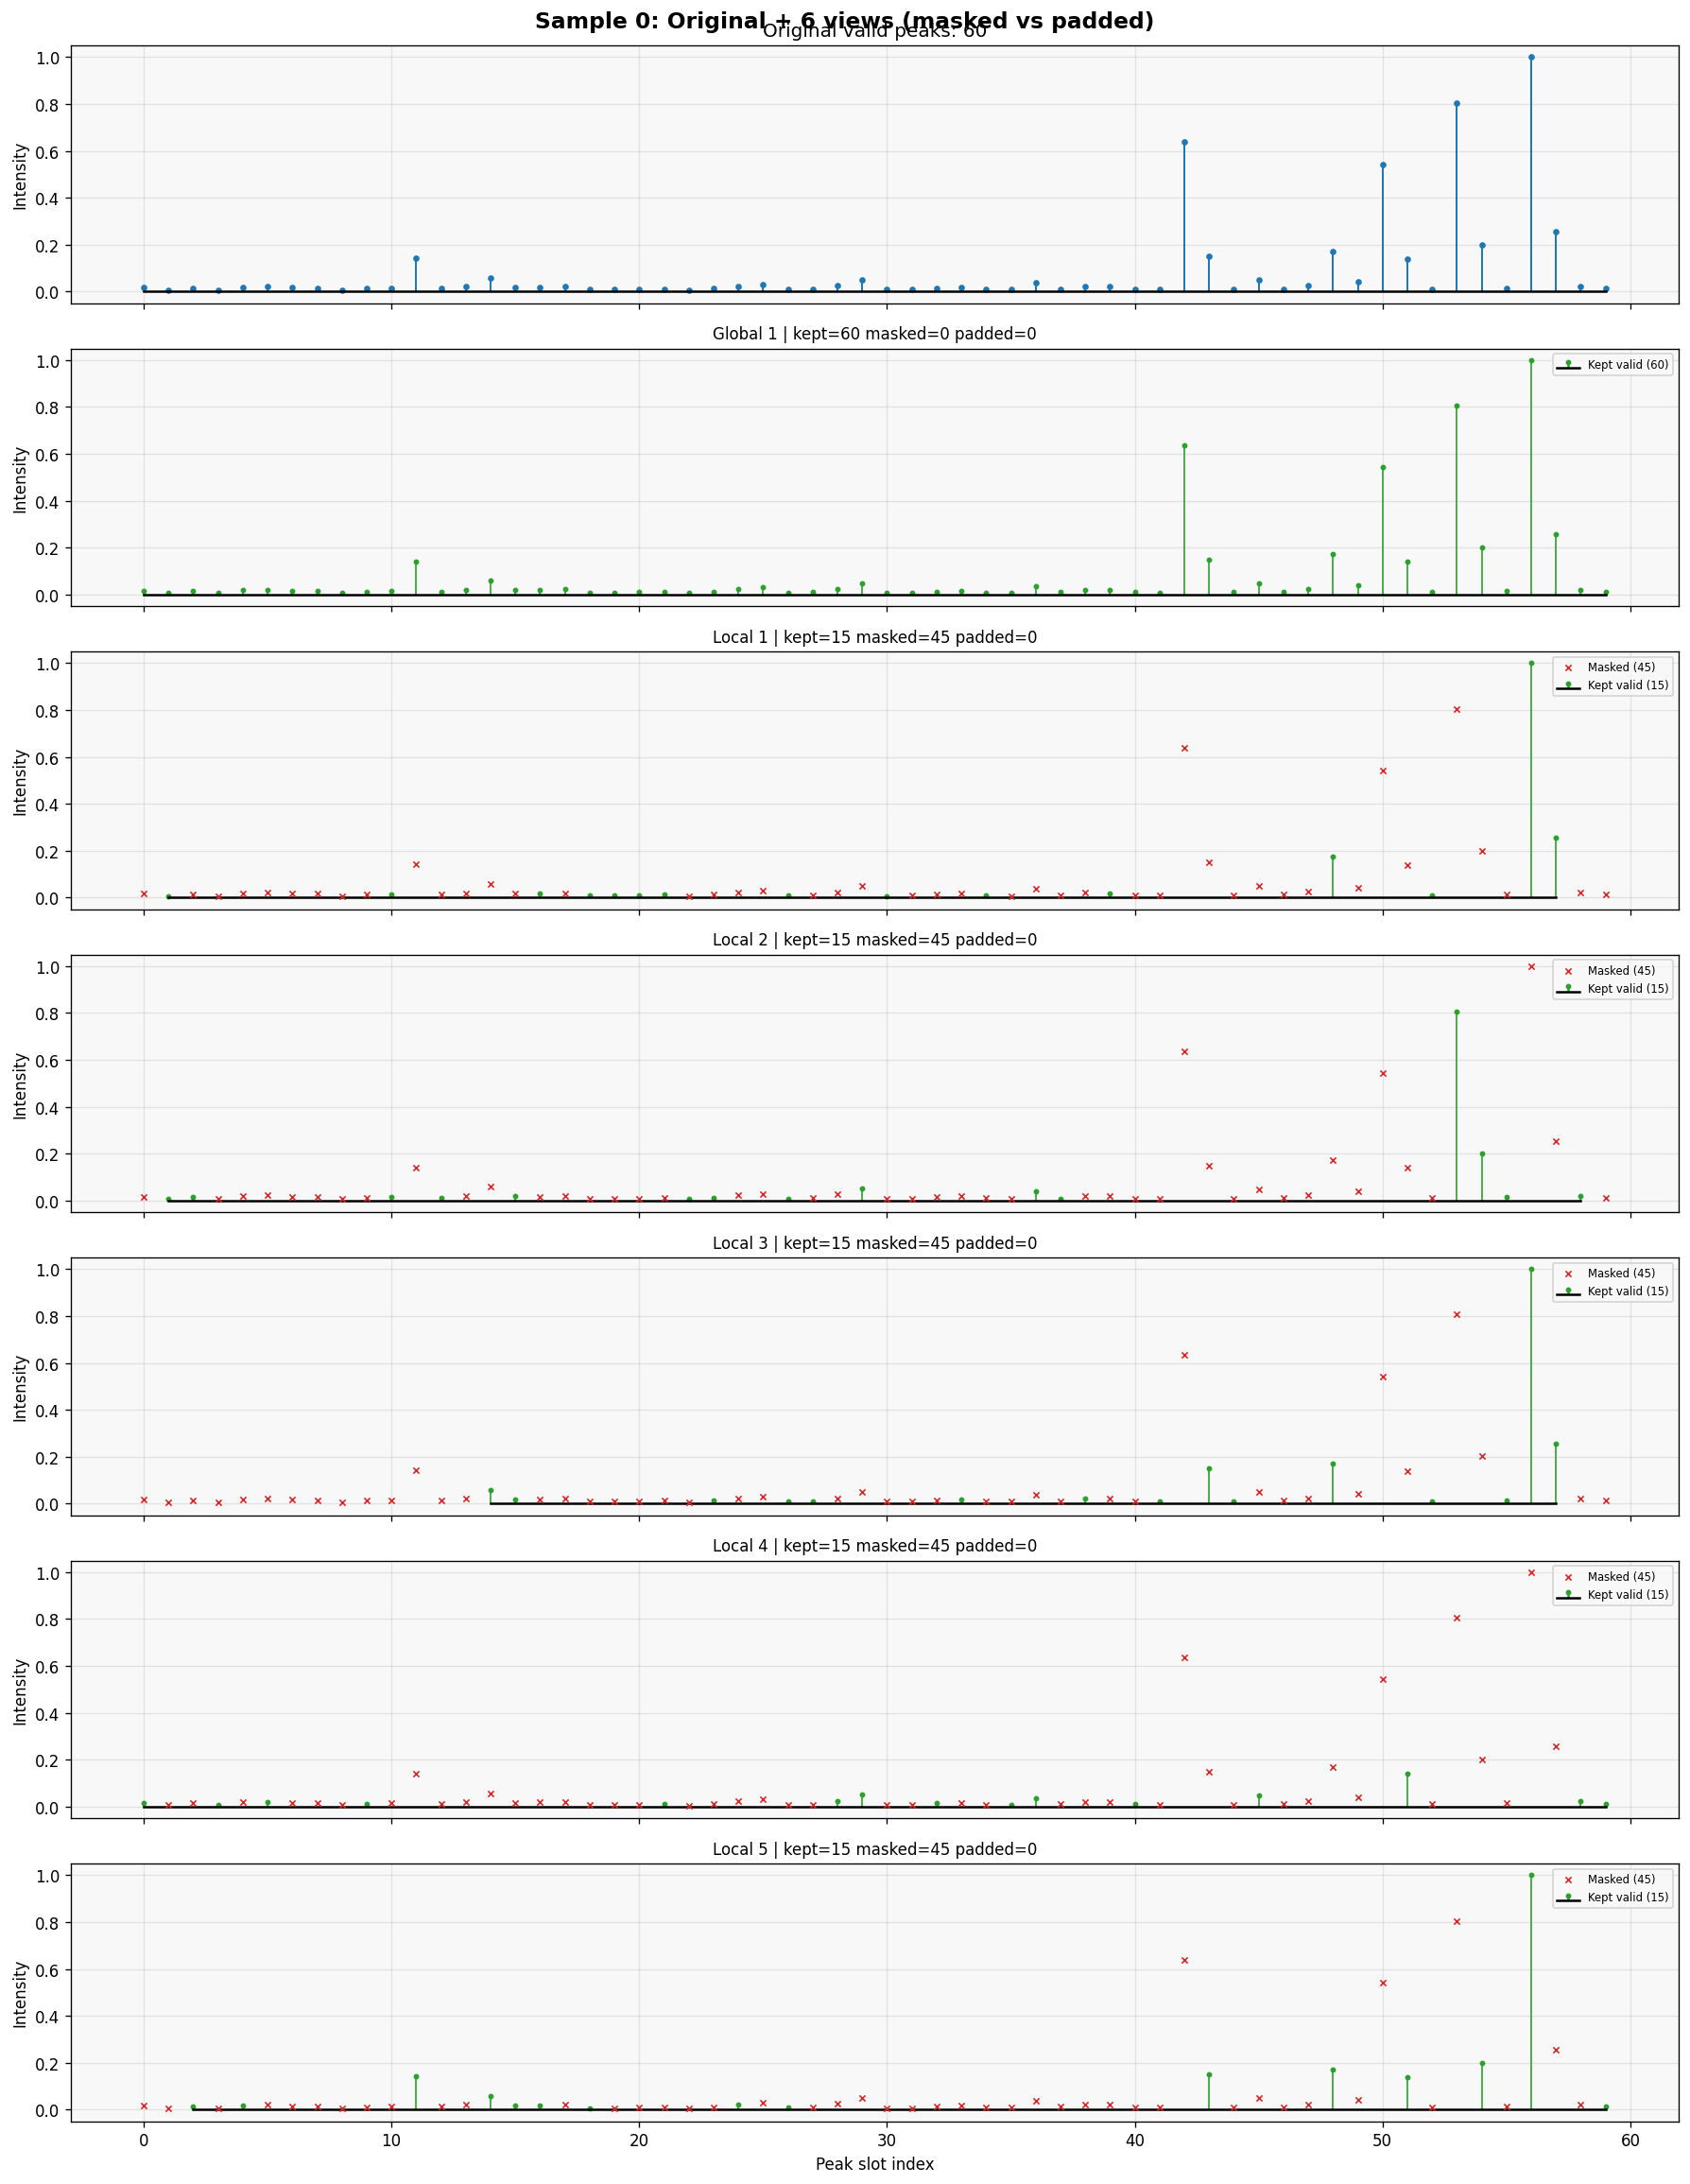

In [6]:
# Compare a single spectrum across all views with explicit masked/padded states
num_global = 1
num_local = cfg.multicrop_num_local_views
V = num_global + num_local
B = raw_batch['peak_mz'].shape[0]
sample_idx = 0

orig_int = raw_batch['peak_intensity'][sample_idx]
orig_valid = raw_batch['peak_valid_mask'][sample_idx].astype(bool)

views = []
for v in range(V):
    offset = v * B + sample_idx
    label = f'Global {v + 1}' if v < num_global else f'Local {v - num_global + 1}'
    views.append({
        'int': aug_batch['fused_intensity'][offset],
        'valid': aug_batch['fused_valid_mask'][offset].astype(bool),
        'masked': aug_batch['fused_masked_positions'][offset].astype(bool),
        'padding': aug_batch['fused_padding_mask'][offset].astype(bool),
        'label': label,
    })

fig, axes = plt.subplots(1 + V, 1, figsize=(15, 2.8 * (1 + V)), sharex=True)
fig.suptitle(
    f'Sample {sample_idx}: Original + {V} views (masked vs padded)',
    fontsize=14,
    fontweight='bold',
)

# Original
ax = axes[0]
orig_slots = np.where(orig_valid)[0]
markerline, stemlines, baseline = ax.stem(
    orig_slots,
    orig_int[orig_valid],
    linefmt='C0-',
    markerfmt='C0o',
    basefmt='k-',
)
stemlines.set_linewidth(1.2)
markerline.set_markersize(3)
ax.set_title(f'Original valid peaks: {orig_valid.sum()}')
ax.set_ylabel('Intensity')

# Views
for i, view in enumerate(views):
    ax = axes[i + 1]
    valid = view['valid']
    masked = view['masked']
    padding = view['padding']
    kept = valid & (~masked)

    if kept.any():
        markerline, stemlines, baseline = ax.stem(
            np.where(kept)[0],
            view['int'][kept],
            linefmt='C2-',
            markerfmt='C2o',
            basefmt='k-',
            label=f'Kept valid ({kept.sum()})',
        )
        stemlines.set_linewidth(1.0)
        markerline.set_markersize(2.5)

    if masked.any():
        ax.scatter(
            np.where(masked)[0],
            view['int'][masked],
            c='C3',
            s=14,
            marker='x',
            linewidths=1.0,
            label=f'Masked ({masked.sum()})',
            zorder=6,
        )

    if padding.any():
        ax.scatter(
            np.where(padding)[0],
            np.full(padding.sum(), 0.005),
            c='gray',
            s=10,
            marker='x',
            alpha=0.5,
            label=f'Padding ({padding.sum()})',
            zorder=5,
        )

    ax.set_title(f"{view['label']} | kept={kept.sum()} masked={masked.sum()} padded={padding.sum()}", fontsize=10)
    ax.set_ylabel('Intensity')
    ax.legend(fontsize=7, loc='upper right')

axes[-1].set_xlabel('Peak slot index')
plt.tight_layout()
plt.savefig('notebooks/fig_all_views_mask_vs_padding.png', bbox_inches='tight')
plt.show()


## 4. Masking & Padding Heatmap

`fused_valid_mask` is fixed across views.
Global view(s) have no masking; local views carry `fused_masked_positions` with local mask rate.


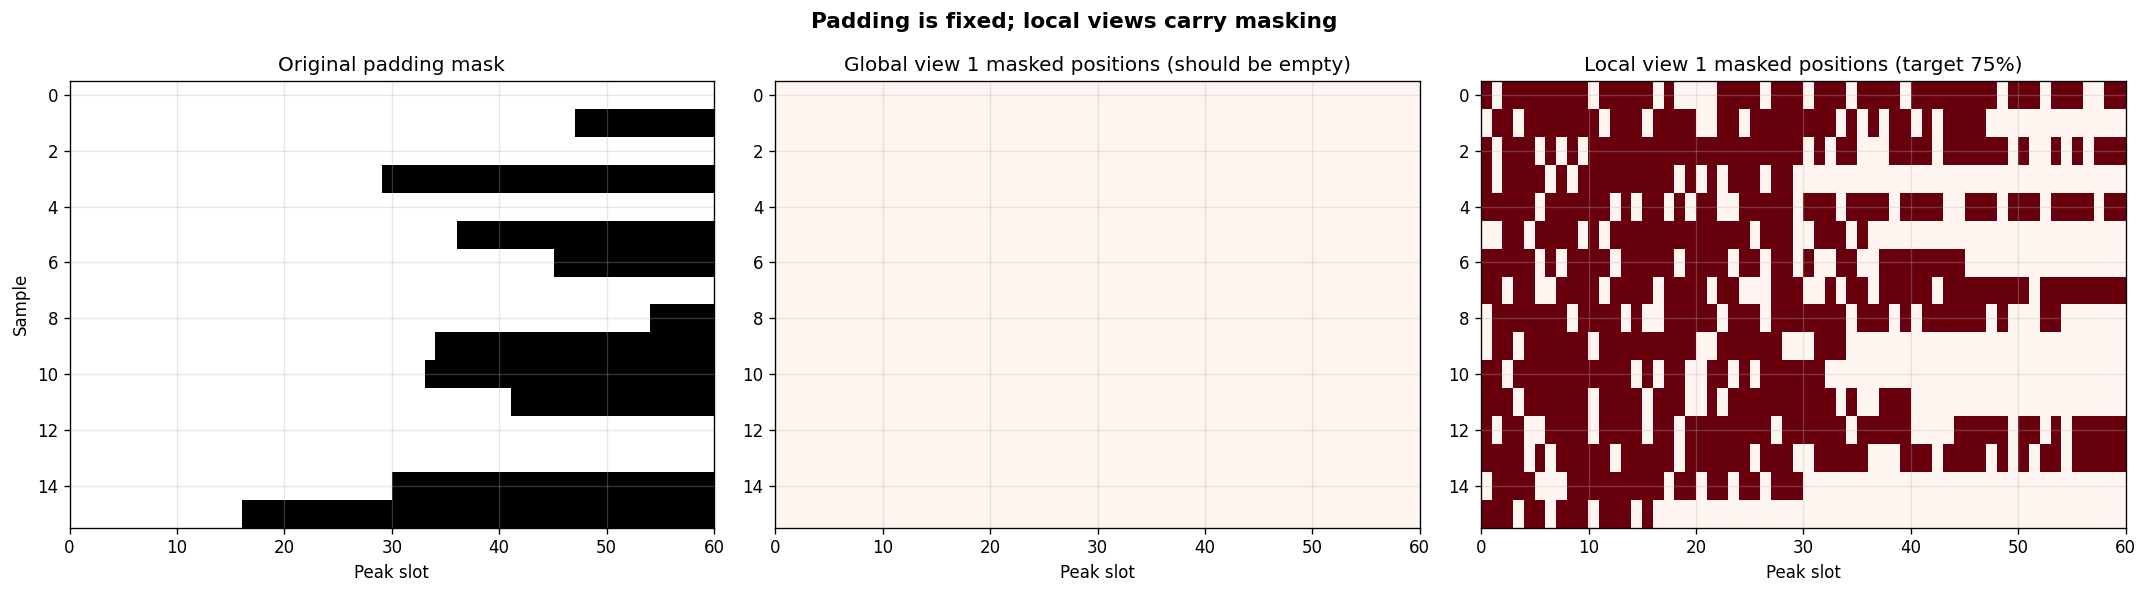

Original avg valid peaks: 45.3
Global view avg masked:  0.0 (target 0)
Local view avg masked:   34.0 (75.0%)


In [7]:
num_global = 1
num_local = cfg.multicrop_num_local_views
V = num_global + num_local
B = raw_batch['peak_mz'].shape[0]
N = _NUM_PEAKS_OUTPUT

orig_valid = raw_batch['peak_valid_mask'][:B].astype(bool)
orig_padding = ~orig_valid
fused_masked = aug_batch['fused_masked_positions'].astype(bool)

global_masked = fused_masked[:B]  # first global view
local_masked = fused_masked[num_global * B:(num_global + 1) * B]  # first local view

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Padding is fixed; local views carry masking', fontsize=13, fontweight='bold')

ax = axes[0]
ax.imshow(orig_padding.astype(float), aspect='auto', cmap='Greys', interpolation='nearest', extent=[0, N, B - 0.5, -0.5])
ax.set_title('Original padding mask')
ax.set_xlabel('Peak slot')
ax.set_ylabel('Sample')

ax = axes[1]
ax.imshow(global_masked.astype(float), aspect='auto', cmap='Reds', interpolation='nearest', extent=[0, N, B - 0.5, -0.5])
ax.set_title('Global view 1 masked positions (should be empty)')
ax.set_xlabel('Peak slot')

ax = axes[2]
ax.imshow(local_masked.astype(float), aspect='auto', cmap='Reds', interpolation='nearest', extent=[0, N, B - 0.5, -0.5])
ax.set_title(f'Local view 1 masked positions (target {1.0 - cfg.multicrop_local_keep_fraction:.0%})')
ax.set_xlabel('Peak slot')

plt.tight_layout()
plt.savefig('notebooks/fig_masking_padding_heatmap.png', bbox_inches='tight')
plt.show()

orig_valid_counts = orig_valid.sum(axis=1)
global_masked_counts = global_masked.sum(axis=1)
local_masked_counts = local_masked.sum(axis=1)

print(f"Original avg valid peaks: {orig_valid_counts.mean():.1f}")
print(f"Global view avg masked:  {global_masked_counts.mean():.1f} (target 0)")
print(f"Local view avg masked:   {local_masked_counts.mean():.1f} ({(local_masked_counts.mean()/orig_valid_counts.mean()):.1%})")


## 5. Fused Batch — Encoder Inputs + Objective Metadata

The encoder consumes:
- `fused_mz` and `fused_intensity`
- `fused_valid_mask` (padding layout)

The masking objective consumes:
- `fused_masked_positions`

Auxiliary visibility fields:
- `fused_padding_mask`
- `peak_padding_mask`


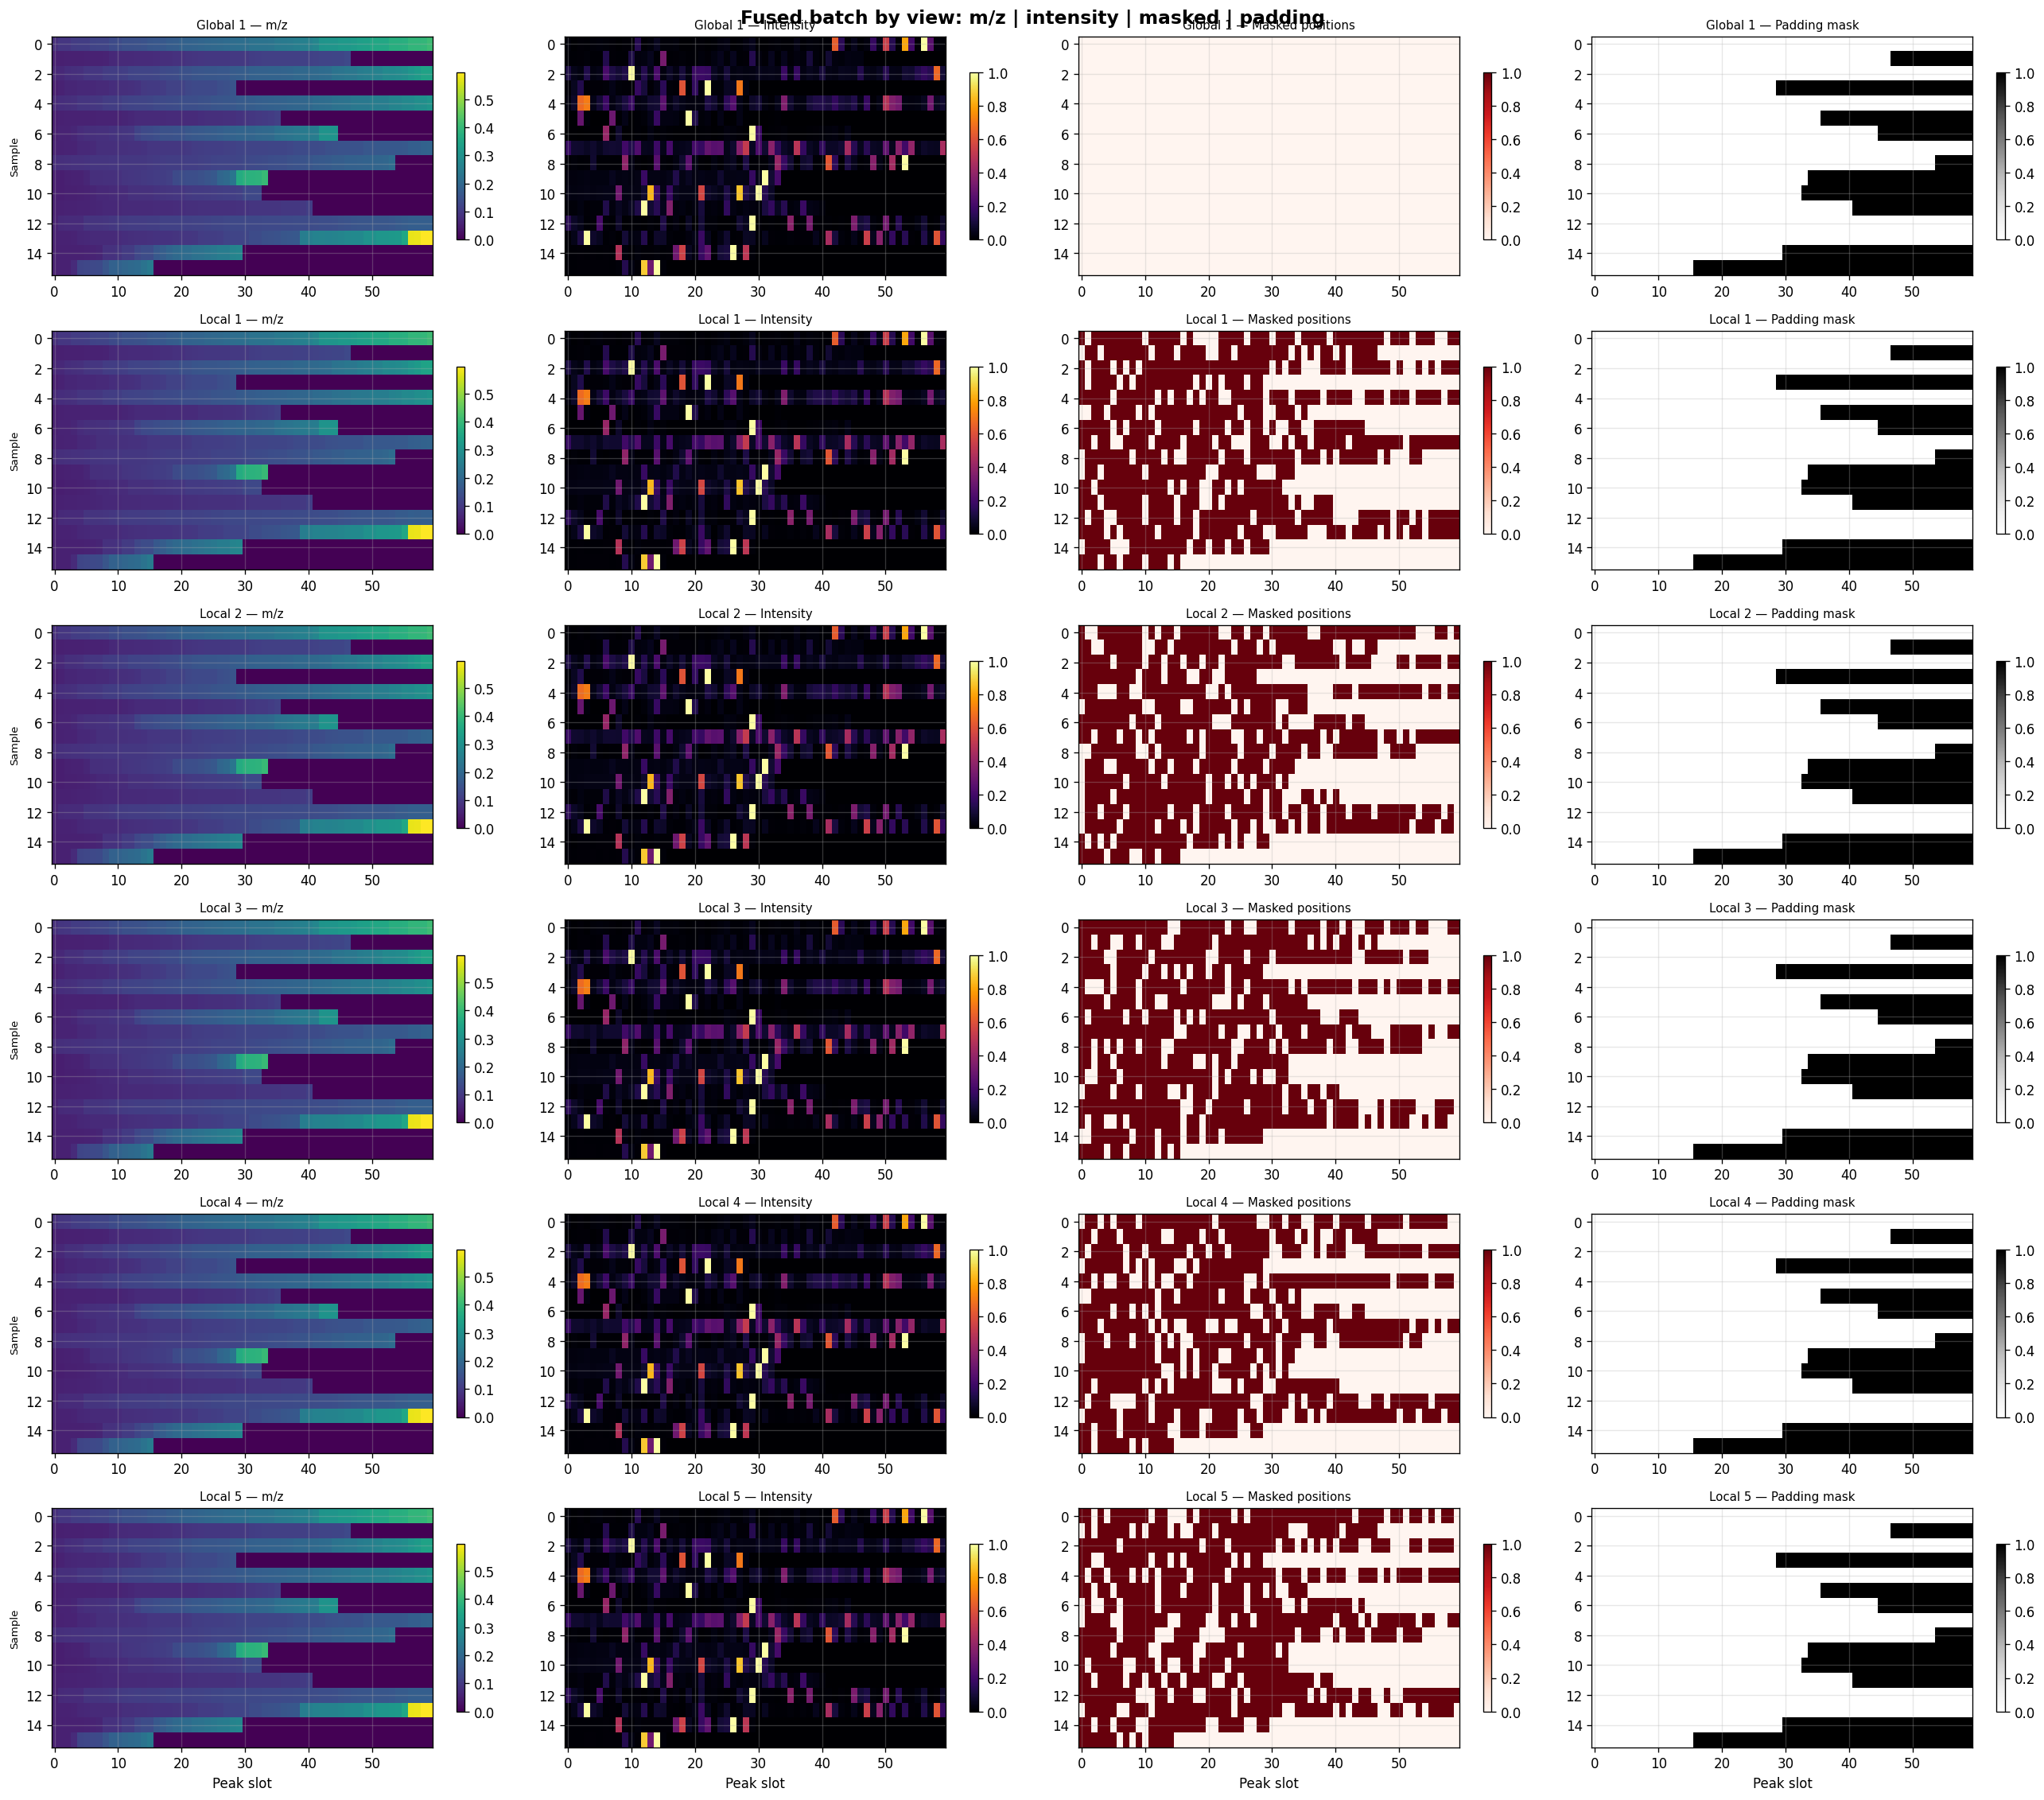

In [8]:
num_global = 1
num_local = cfg.multicrop_num_local_views
V = num_global + num_local
B = raw_batch['peak_mz'].shape[0]

fused_mz = aug_batch['fused_mz']
fused_int = aug_batch['fused_intensity']
fused_masked = aug_batch['fused_masked_positions'].astype(float)
fused_padding = aug_batch['fused_padding_mask'].astype(float)

fig, axes = plt.subplots(V, 4, figsize=(22, 3.2 * V))
fig.suptitle(f'Fused batch by view: m/z | intensity | masked | padding', fontsize=14, fontweight='bold')

for v in range(V):
    sl = slice(v * B, (v + 1) * B)
    if v < num_global:
        label = f'Global {v + 1}'
    else:
        label = f'Local {v - num_global + 1}'

    ax = axes[v, 0]
    im = ax.imshow(fused_mz[sl], aspect='auto', cmap='viridis', interpolation='nearest')
    ax.set_title(f'{label} — m/z', fontsize=9)
    ax.set_ylabel('Sample', fontsize=8)
    plt.colorbar(im, ax=ax, shrink=0.7)

    ax = axes[v, 1]
    im = ax.imshow(fused_int[sl], aspect='auto', cmap='inferno', interpolation='nearest')
    ax.set_title(f'{label} — Intensity', fontsize=9)
    plt.colorbar(im, ax=ax, shrink=0.7)

    ax = axes[v, 2]
    im = ax.imshow(fused_masked[sl], aspect='auto', cmap='Reds', interpolation='nearest', vmin=0, vmax=1)
    ax.set_title(f'{label} — Masked positions', fontsize=9)
    plt.colorbar(im, ax=ax, shrink=0.7)

    ax = axes[v, 3]
    im = ax.imshow(fused_padding[sl], aspect='auto', cmap='Greys', interpolation='nearest', vmin=0, vmax=1)
    ax.set_title(f'{label} — Padding mask', fontsize=9)
    plt.colorbar(im, ax=ax, shrink=0.7)

for ax in axes[-1]:
    ax.set_xlabel('Peak slot')

plt.tight_layout()
plt.savefig('notebooks/fig_fused_batch_inputs_and_metadata.png', bbox_inches='tight')
plt.show()


## 6. Jitter Effect Visualization

Compare repeated augmentations for the same spectrum across global views to see jitter distribution.

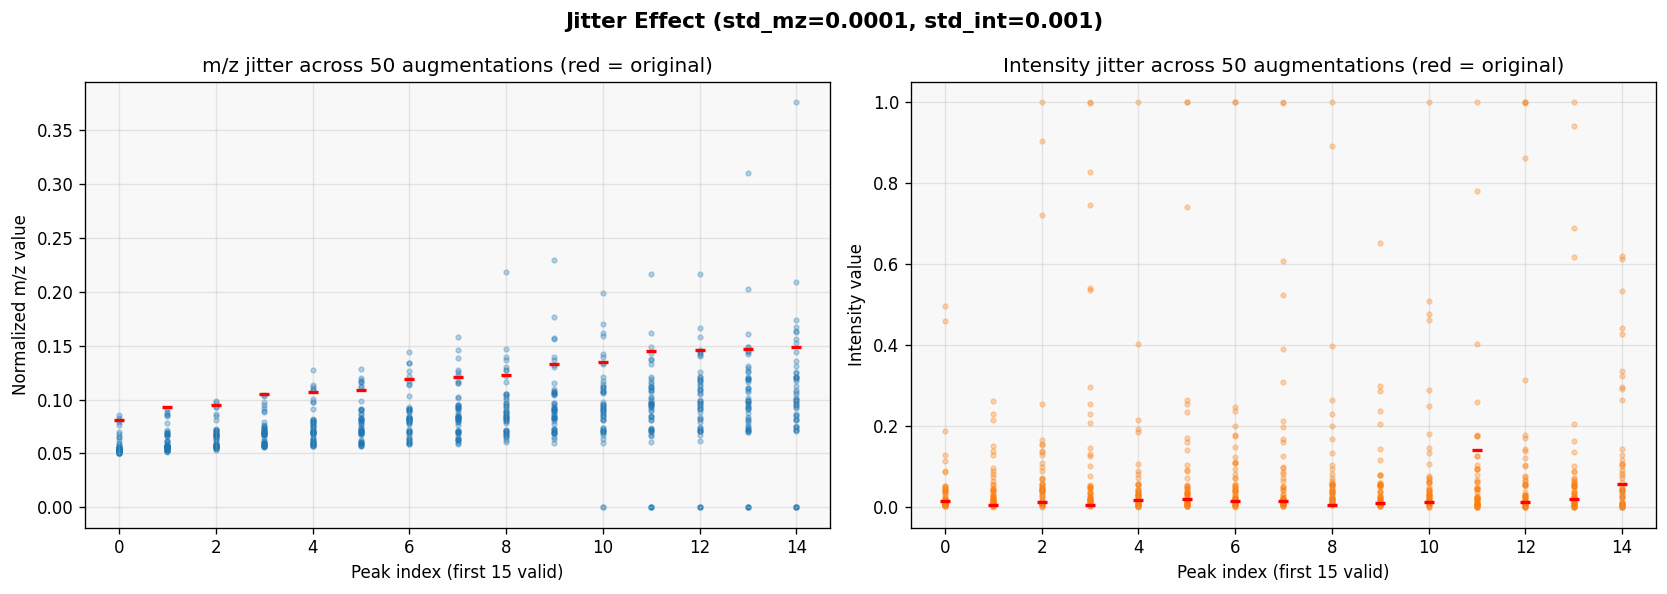

In [9]:
# Run augmentation multiple times to see jitter distribution on global view 1
n_runs = 50
sample_idx = 0

orig_mz_s = raw_batch['peak_mz'][sample_idx]
orig_int_s = raw_batch['peak_intensity'][sample_idx]
orig_valid_s = raw_batch['peak_valid_mask'][sample_idx].astype(bool)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Jitter Effect (std_mz={cfg.sigreg_mz_jitter_std}, std_int={cfg.sigreg_intensity_jitter_std})',
             fontsize=13, fontweight='bold')

# Collect global view 1 from multiple augmentations
jittered_mz_all = []
jittered_int_all = []
for _ in range(n_runs):
    ab = next(aug_ds.as_numpy_iterator())
    jittered_mz_all.append(ab['fused_mz'][sample_idx])  # global view 1
    jittered_int_all.append(ab['fused_intensity'][sample_idx])

jittered_mz_all = np.stack(jittered_mz_all)
jittered_int_all = np.stack(jittered_int_all)

# m/z jitter
ax = axes[0]
valid_peaks = np.where(orig_valid_s)[0][:15]  # first 15 valid peaks
for i, pk in enumerate(valid_peaks):
    vals = jittered_mz_all[:, pk]
    orig_val = orig_mz_s[pk]
    ax.scatter(np.full_like(vals, i), vals, alpha=0.3, s=8, c='C0')
    ax.scatter(i, orig_val, c='red', s=30, marker='_', linewidths=2, zorder=5)
ax.set_xlabel('Peak index (first 15 valid)')
ax.set_ylabel('Normalized m/z value')
ax.set_title('m/z jitter across 50 augmentations (red = original)')

# Intensity jitter
ax = axes[1]
for i, pk in enumerate(valid_peaks):
    vals = jittered_int_all[:, pk]
    orig_val = orig_int_s[pk]
    ax.scatter(np.full_like(vals, i), vals, alpha=0.3, s=8, c='C1')
    ax.scatter(i, orig_val, c='red', s=30, marker='_', linewidths=2, zorder=5)
ax.set_xlabel('Peak index (first 15 valid)')
ax.set_ylabel('Intensity value')
ax.set_title('Intensity jitter across 50 augmentations (red = original)')

plt.tight_layout()
plt.savefig('notebooks/fig_jitter.png', bbox_inches='tight')
plt.show()

## 7. Fourier Features — What the Encoder Embeds

The encoder first applies `FourierFeatures` to normalized m/z values, producing a [B, N, 128] tensor of sin/cos features at log-spaced frequencies from 1 Hz to 5000 Hz.

In [10]:
import torch

# Local Fourier feature helper (matches model's 128-dim sinusoidal projection).
def ff(mz_tensor: torch.Tensor) -> torch.Tensor:
    freqs = torch.logspace(0.0, 2.0, steps=64, device=mz_tensor.device, dtype=mz_tensor.dtype)
    phases = 2.0 * torch.pi * mz_tensor.unsqueeze(-1) * freqs
    return torch.cat([torch.sin(phases), torch.cos(phases)], dim=-1)


## 8. End-to-End Single-Sample Journey

One spectrum through every stage, emphasizing the new split between:
- encoder-visible structure (`valid`/`padding`), and
- objective masking (`masked_positions`) per view.


/tmp/ipykernel_2822119/2585405516.py:54: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  orig_mz_torch = torch.from_numpy(o_mz[np.newaxis]).float()


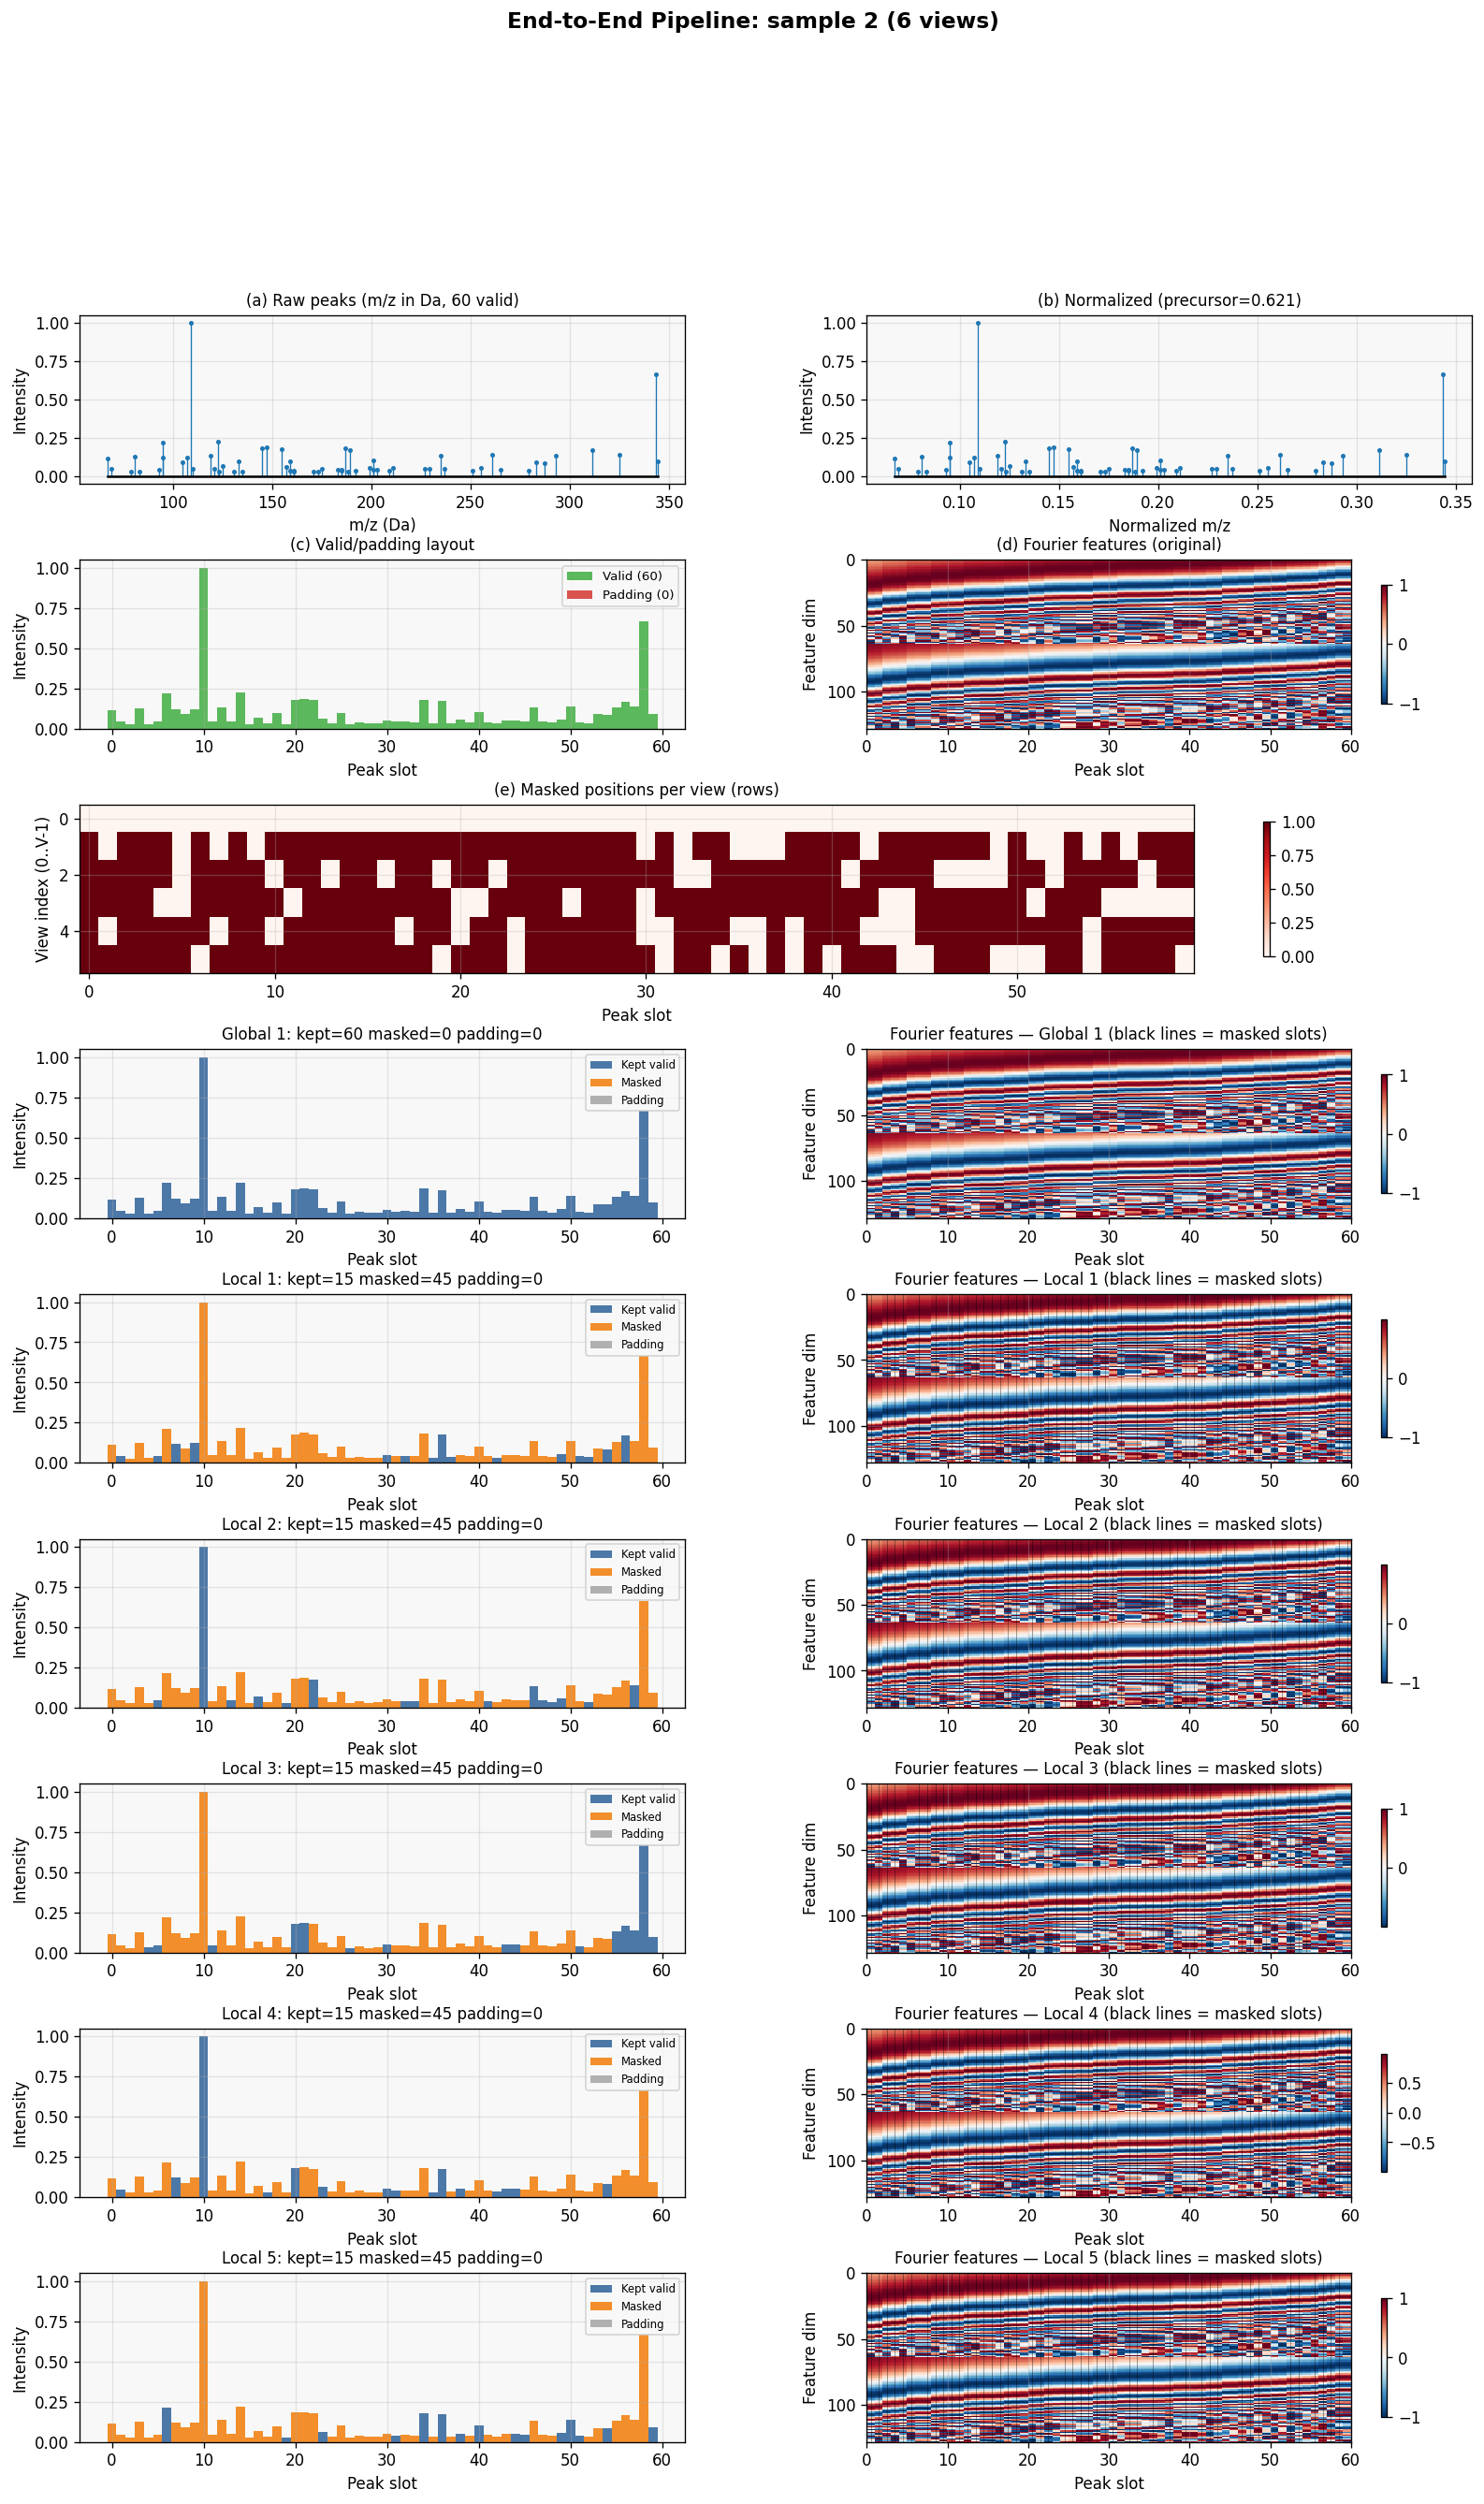

In [11]:
idx = 2
num_global = 1
num_local = cfg.multicrop_num_local_views
V = num_global + num_local
B = raw_batch['peak_mz'].shape[0]

fig = plt.figure(figsize=(16, 6 + 3.1 * V))
nrows = 3 + V
gs = gridspec.GridSpec(nrows, 2, figure=fig, hspace=0.45, wspace=0.3)
fig.suptitle(f'End-to-End Pipeline: sample {idx} ({V} views)', fontsize=14, fontweight='bold', y=0.99)

o_mz = raw_batch['peak_mz'][idx]
o_int = raw_batch['peak_intensity'][idx]
o_valid = raw_batch['peak_valid_mask'][idx].astype(bool)
o_prec = raw_batch['precursor_mz'][idx]
o_raw_mz = raw_batch['mz'][idx]
o_raw_int = raw_batch['intensity'][idx]

# (a) Raw spectrum (un-normalized)
ax = fig.add_subplot(gs[0, 0])
v_idx = np.where(o_valid)[0]
if len(v_idx) > 0:
    markerline, stemlines, baseline = ax.stem(o_raw_mz[v_idx], o_raw_int[v_idx], linefmt='C0-', markerfmt='C0o', basefmt='k-')
    stemlines.set_linewidth(0.8)
    markerline.set_markersize(2)
ax.set_title(f'(a) Raw peaks (m/z in Da, {len(v_idx)} valid)', fontsize=10)
ax.set_xlabel('m/z (Da)')
ax.set_ylabel('Intensity')

# (b) Normalized spectrum
ax = fig.add_subplot(gs[0, 1])
if len(v_idx) > 0:
    markerline, stemlines, baseline = ax.stem(o_mz[v_idx], o_int[v_idx], linefmt='C0-', markerfmt='C0o', basefmt='k-')
    stemlines.set_linewidth(0.8)
    markerline.set_markersize(2)
ax.set_title(f'(b) Normalized (precursor={o_prec:.3f})', fontsize=10)
ax.set_xlabel('Normalized m/z')
ax.set_ylabel('Intensity')

# (c) Valid + padding
ax = fig.add_subplot(gs[1, 0])
colors = ['#5cb85c' if v else '#d9534f' for v in o_valid]
ax.bar(range(_NUM_PEAKS_OUTPUT), o_int, color=colors, width=1.0, edgecolor='none')
ax.set_title('(c) Valid/padding layout', fontsize=10)
ax.set_xlabel('Peak slot')
ax.set_ylabel('Intensity')
ax.legend(handles=[
    Patch(facecolor='#5cb85c', label=f'Valid ({o_valid.sum()})'),
    Patch(facecolor='#d9534f', label=f'Padding ({(~o_valid).sum()})'),
], fontsize=8)

# (d) Fourier features of original mz
ax = fig.add_subplot(gs[1, 1])
orig_mz_torch = torch.from_numpy(o_mz[np.newaxis]).float()
with torch.no_grad():
    ff_orig = ff(orig_mz_torch)[0].numpy()
im = ax.imshow(ff_orig.T, aspect='auto', cmap='RdBu_r', interpolation='nearest', extent=[0, _NUM_PEAKS_OUTPUT, 128, 0])
ax.set_title('(d) Fourier features (original)', fontsize=10)
ax.set_xlabel('Peak slot')
ax.set_ylabel('Feature dim')
plt.colorbar(im, ax=ax, shrink=0.7)

# (e) Mask map across all views
ax = fig.add_subplot(gs[2, :])
view_mask_map = []
for v in range(V):
    offset = v * B + idx
    view_mask_map.append(aug_batch['fused_masked_positions'][offset].astype(float))
view_mask_map = np.stack(view_mask_map)
im = ax.imshow(view_mask_map, aspect='auto', cmap='Reds', interpolation='nearest', vmin=0, vmax=1)
ax.set_title('(e) Masked positions per view (rows)', fontsize=10)
ax.set_xlabel('Peak slot')
ax.set_ylabel('View index (0..V-1)')
plt.colorbar(im, ax=ax, shrink=0.8)

# (f...) Per-view state + Fourier features
for v in range(V):
    row = 3 + v
    offset = v * B + idx
    v_int = aug_batch['fused_intensity'][offset]
    v_valid = aug_batch['fused_valid_mask'][offset].astype(bool)
    v_masked = aug_batch['fused_masked_positions'][offset].astype(bool)
    v_padding = aug_batch['fused_padding_mask'][offset].astype(bool)

    if v < num_global:
        label = f'Global {v + 1}'
    else:
        label = f'Local {v - num_global + 1}'

    ax = fig.add_subplot(gs[row, 0])
    bar_colors = np.full(_NUM_PEAKS_OUTPUT, '#4c78a8', dtype=object)  # kept valid
    bar_colors[v_masked] = '#f28e2b'  # masked
    bar_colors[v_padding] = '#b0b0b0'  # padding
    ax.bar(range(_NUM_PEAKS_OUTPUT), v_int, color=bar_colors, width=1.0, edgecolor='none')
    ax.set_title(
        f'{label}: kept={(v_valid & ~v_masked).sum()} masked={v_masked.sum()} padding={v_padding.sum()}',
        fontsize=10,
    )
    ax.set_xlabel('Peak slot')
    ax.set_ylabel('Intensity')
    ax.legend(handles=[
        Patch(facecolor='#4c78a8', label='Kept valid'),
        Patch(facecolor='#f28e2b', label='Masked'),
        Patch(facecolor='#b0b0b0', label='Padding'),
    ], fontsize=7)

    ax_ff = fig.add_subplot(gs[row, 1])
    v_mz_torch = torch.from_numpy(aug_batch['fused_mz'][offset][np.newaxis]).float()
    with torch.no_grad():
        ff_v = ff(v_mz_torch)[0].numpy()
    im = ax_ff.imshow(ff_v.T, aspect='auto', cmap='RdBu_r', interpolation='nearest', extent=[0, _NUM_PEAKS_OUTPUT, 128, 0])
    masked_slots = np.where(v_masked)[0]
    for s in masked_slots:
        ax_ff.axvline(s + 0.5, color='black', lw=0.6, alpha=0.35)
    ax_ff.set_title(f'Fourier features — {label} (black lines = masked slots)', fontsize=10)
    ax_ff.set_xlabel('Peak slot')
    ax_ff.set_ylabel('Feature dim')
    plt.colorbar(im, ax=ax_ff, shrink=0.7)

plt.savefig('notebooks/fig_pipeline_journey_mask_metadata.png', bbox_inches='tight')
plt.show()


## 9. Batch Statistics Summary

Aggregate view statistics in the new mode:
- valid/padding layout invariance across views
- global views are full spectra (0 masking)
- local views carry masking at local percentage
- value distributions for kept/masked/padded positions


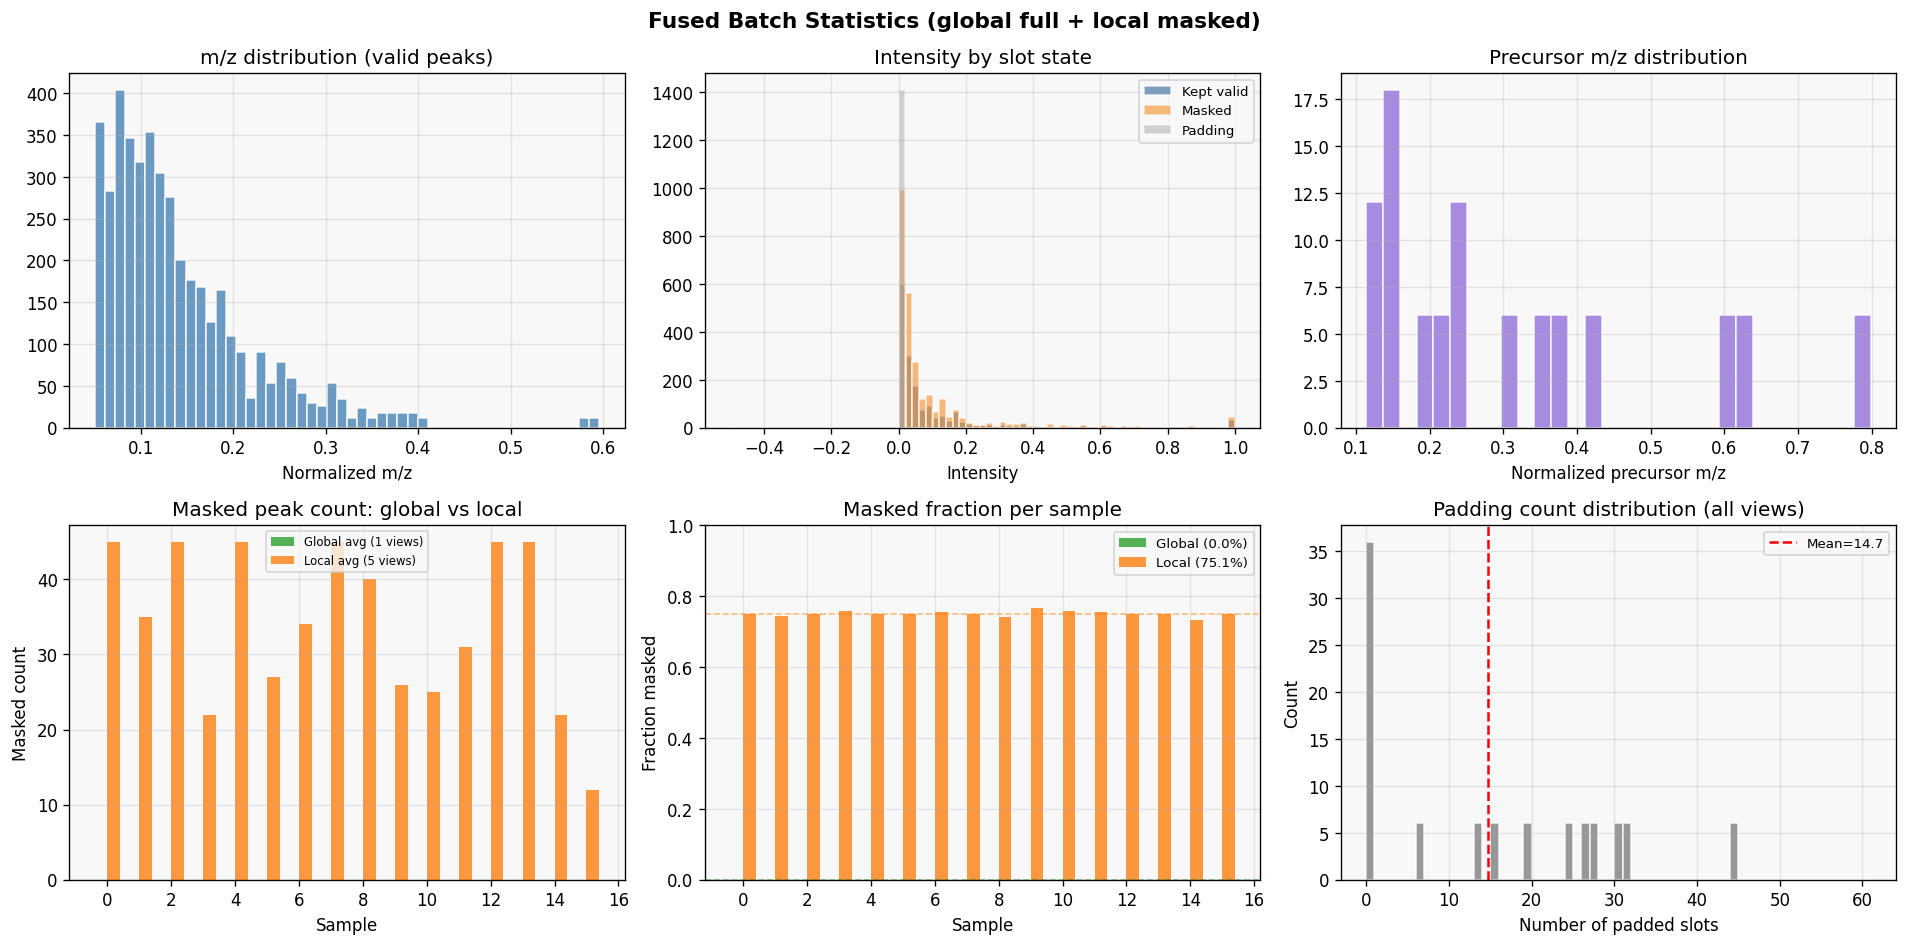


Summary:
  Batch shape: fused_mz=(96, 60), fused_intensity=(96, 60)
  V=6 views (global=1, local=5), B=16
  Valid layout stable across views: True
  Masked subset of valid: True
  Padding = ~valid: True
  Global avg masked peaks: 0.0 / 45.3
  Local avg masked peaks:  34.0 / 45.3
  Global masked fraction: 0.0% (target 0%)
  Local masked fraction:  75.1% (target 75%)
  m/z range (valid): [0.0504, 0.5957]
  Intensity range (kept): [0.0007, 1.0000]


In [12]:
num_global = 1
num_local = cfg.multicrop_num_local_views
V = num_global + num_local
B = raw_batch['peak_mz'].shape[0]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Fused Batch Statistics (global full + local masked)', fontsize=13, fontweight='bold')

fmz = aug_batch['fused_mz']
fi = aug_batch['fused_intensity']
fv = aug_batch['fused_valid_mask'].astype(bool)
fm = aug_batch['fused_masked_positions'].astype(bool)
fpad = aug_batch['fused_padding_mask'].astype(bool)
fp = aug_batch['fused_precursor_mz']

kept = fv & (~fm)

# (a) m/z distribution (valid peaks only)
ax = axes[0, 0]
valid_mz = fmz[fv]
ax.hist(valid_mz, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_title('m/z distribution (valid peaks)')
ax.set_xlabel('Normalized m/z')

# (b) Intensity distribution by state
ax = axes[0, 1]
kept_int = fi[kept]
masked_int = fi[fm]
padded_int = fi[fpad]
ax.hist(kept_int, bins=50, color='#4c78a8', edgecolor='white', alpha=0.7, label='Kept valid')
if len(masked_int) > 0:
    ax.hist(masked_int, bins=50, color='#f28e2b', edgecolor='white', alpha=0.6, label='Masked')
if len(padded_int) > 0:
    ax.hist(padded_int, bins=50, color='#aaaaaa', edgecolor='white', alpha=0.5, label='Padding')
ax.set_title('Intensity by slot state')
ax.set_xlabel('Intensity')
ax.legend(fontsize=8)

# (c) Precursor m/z distribution
ax = axes[0, 2]
ax.hist(fp, bins=30, color='mediumpurple', edgecolor='white', alpha=0.8)
ax.set_title('Precursor m/z distribution')
ax.set_xlabel('Normalized precursor m/z')

# (d) Masked count per sample: global vs local
ax = axes[1, 0]
global_masked = []
local_masked = []
for v in range(num_global):
    sl = slice(v * B, (v + 1) * B)
    global_masked.append(fm[sl].sum(axis=1))
for v in range(num_local):
    sl = slice((num_global + v) * B, (num_global + v + 1) * B)
    local_masked.append(fm[sl].sum(axis=1))
global_all = np.stack(global_masked)
local_all = np.stack(local_masked)

x = np.arange(B)
ax.bar(x - 0.2, global_all.mean(axis=0), 0.4, label=f'Global avg ({num_global} views)', color='C2', alpha=0.8)
ax.bar(x + 0.2, local_all.mean(axis=0), 0.4, label=f'Local avg ({num_local} views)', color='C1', alpha=0.8)
ax.set_title('Masked peak count: global vs local')
ax.set_xlabel('Sample')
ax.set_ylabel('Masked count')
ax.legend(fontsize=7)

# (e) Masked fraction per sample
ax = axes[1, 1]
orig_counts = raw_batch['peak_valid_mask'][:B].sum(axis=1)
safe_orig = np.maximum(orig_counts, 1)
global_mask_frac = global_all.mean(axis=0) / safe_orig
local_mask_frac = local_all.mean(axis=0) / safe_orig
ax.bar(x - 0.2, global_mask_frac, 0.4, color='C2', alpha=0.8, label=f'Global ({global_mask_frac.mean():.1%})')
ax.bar(x + 0.2, local_mask_frac, 0.4, color='C1', alpha=0.8, label=f'Local ({local_mask_frac.mean():.1%})')
ax.axhline(0.0, color='C2', ls='--', lw=1, alpha=0.5)
ax.axhline(1.0 - cfg.multicrop_local_keep_fraction, color='C1', ls='--', lw=1, alpha=0.5)
ax.set_title('Masked fraction per sample')
ax.set_xlabel('Sample')
ax.set_ylabel('Fraction masked')
ax.set_ylim(0, 1)
ax.legend(fontsize=8)

# (f) Padding count distribution
ax = axes[1, 2]
pad_counts = fpad.sum(axis=1)
ax.hist(pad_counts, bins=range(0, _NUM_PEAKS_OUTPUT + 2), color='gray', edgecolor='white', alpha=0.8)
ax.axvline(pad_counts.mean(), color='red', ls='--', label=f'Mean={pad_counts.mean():.1f}')
ax.set_title('Padding count distribution (all views)')
ax.set_xlabel('Number of padded slots')
ax.set_ylabel('Count')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('notebooks/fig_batch_stats_mask_metadata.png', bbox_inches='tight')
plt.show()

valid_layout_stable = np.array_equal(
    fv,
    np.tile(raw_batch['peak_valid_mask'][:B].astype(bool), (V, 1)),
)

print()
print('Summary:')
print(f'  Batch shape: fused_mz={fmz.shape}, fused_intensity={fi.shape}')
print(f'  V={V} views (global={num_global}, local={num_local}), B={B}')
print(f'  Valid layout stable across views: {valid_layout_stable}')
print(f'  Masked subset of valid: {bool(np.all(~fm | fv))}')
print(f'  Padding = ~valid: {bool(np.array_equal(fpad, ~fv))}')
print(f'  Global avg masked peaks: {global_all.mean():.1f} / {orig_counts.mean():.1f}')
print(f'  Local avg masked peaks:  {local_all.mean():.1f} / {orig_counts.mean():.1f}')
print(f'  Global masked fraction: {global_mask_frac.mean():.1%} (target 0%)')
print(f'  Local masked fraction:  {local_mask_frac.mean():.1%} (target {1.0 - cfg.multicrop_local_keep_fraction:.0%})')
print(f'  m/z range (valid): [{valid_mz.min():.4f}, {valid_mz.max():.4f}]')
print(f'  Intensity range (kept): [{kept_int.min():.4f}, {kept_int.max():.4f}]')
